<a href="https://colab.research.google.com/github/FilippoGib/Chess_Engine/blob/main/Chess_Engine_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

{}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory


In [3]:
# !ls -lah ~ | grep kaggle

In [4]:
!kaggle datasets download -d nikitricky/chess-positions

Dataset URL: https://www.kaggle.com/datasets/nikitricky/chess-positions
License(s): DbCL-1.0
  0% 0.00/18.4M [00:00<?, ?B/s]
100% 18.4M/18.4M [00:00<00:00, 940MB/s]


In [5]:
!unzip chess-positions.zip -d /content/data

Archive:  chess-positions.zip
replace /content/data/positions.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [6]:
! rm -r /content/chess-positions.zip /content/kaggle.json

rm: cannot remove '/content/kaggle.json': No such file or directory


In [7]:
import numpy as np
import pandas as pd
import sklearn
import torch

!pip install chess
import chess

In [8]:
#Reading in our training data
df = pd.read_csv("/content/data/positions.csv")

/tmp/ipython-input-263116981.py:2: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/data/positions.csv")


In [9]:
# just keep the fen position and the score
df.drop(columns=[c for c in df.columns if c not in ["fen", "score"]], inplace=True)
df.dropna(inplace=True) # if we don't have an evaluation we don't want that position

In [10]:
# we split the dataset in features and labels
positions = np.asanyarray(df["fen"].tolist())
evaluations = np.asanyarray(df["score"].tolist())

In [11]:
# take a look at tha data
print(positions[:10])
print(evaluations[:10])

['rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1'
 'rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2'
 'rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBNR b KQkq - 0 2'
 'rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/8/PPP2PPP/RNBQKBNR w KQkq - 0 3'
 'rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/P7/1PP2PPP/RNBQKBNR b KQkq - 0 3'
 'rn1qkbnr/pbpp1ppp/1p2p3/8/3PP3/P7/1PP2PPP/RNBQKBNR w KQkq - 1 4'
 'rn1qkbnr/pbpp1ppp/1p2p3/8/3PP3/P1N5/1PP2PPP/R1BQKBNR b KQkq - 2 4'
 'rn1qkb1r/pbpp1ppp/1p2p2n/8/3PP3/P1N5/1PP2PPP/R1BQKBNR w KQkq - 3 5'
 'rn1qkb1r/pbpp1ppp/1p2p2B/8/3PP3/P1N5/1PP2PPP/R2QKBNR b KQkq - 0 5'
 'rn1qkb1r/pbpp1p1p/1p2p2p/8/3PP3/P1N5/1PP2PPP/R2QKBNR w KQkq - 0 6']
[ -35.   36.  -27.   81.  -65.   67.  -60.  151. -120.  123.]


In [12]:
# this function converts from Forsyth-Edwards chess notation to an array
def FENtoVEC (FEN):
    pieces = {"r":-5,"n":-3,"b":-3.2,"q":-9.5,"k":-100,"p":-1,"R":5,"N":3,"B":3.2,"Q":9.5,"K":100,"P":1}
    position = FEN.split()[0]
    turn = FEN.split()[1]
    ret = []
    for i in range(len(position)):
        if position[i] == "/":
            continue
        if position[i] in pieces:
            ret.append(pieces[position[i]])
        else:
          ret.extend([0] * int(position[i])) # if the current value is not a letter but a number we need to append that number of zeros to the vector

    # simplest way to encode who's turn it is
    if turn == "w":
        ret.extend([1.0,0.0])
    else:
        ret.extend([0.0,1.0])
    return ret

''' OSS: instead of representig the single cell as a one-hot encoded vector with 12 dimension (6 possible pieces x 2 colors) we assign to the cell the value of the piece itself: a rook is 5, a queen is 9 etc... and for the black pieces we just put a negative value, this is also reflected in the fact that we encode -1 as "black completely winning" and +1 as "white completely winning" '''

' OSS: instead of representig the single cell as a one-hot encoded vector with 12 dimension (6 possible pieces x 2 colors) we assign to the cell the value of the piece itself: a rook is 5, a queen is 9 etc... and for the black pieces we just put a negative value, this is also reflected in the fact that we encode -1 as "black completely winning" and +1 as "white completely winning" '

In [13]:
# # This function maps values into -1,1 without clipping first
# def map_in_minus_1_plus_1(vec):
#   old_max = vec.max()
#   old_min = vec.min()
#   new_max = 1
#   new_min = -1
#   ret = []
#   for i in range(len(vec)):
#     ret.append(new_min + ((vec[i]-old_min)/(old_max-old_min))*(new_max-new_min))

In [14]:
# convert the positions to numeric values
positions = np.asarray([FENtoVEC(position) for position in positions])
# normalize everything
positions = positions / 100.0 # 100 = king's value
evaluations = np.clip(evaluations, -1000, 1000) / 1000 # I clip and normalize wrt 1000 centipawns which is 10 point of material, this is because there isn't really a difference in being winning by 10 points or 30

In [15]:
# take a look at tha data
print(positions[0])

[-0.05  -0.03  -0.032 -0.095 -1.    -0.032 -0.03  -0.05  -0.01  -0.01
 -0.01  -0.01  -0.01  -0.01  -0.01  -0.01   0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.01   0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.01   0.01
  0.01   0.01   0.     0.01   0.01   0.01   0.05   0.03   0.032  0.095
  1.     0.032  0.03   0.05   0.     0.01 ]


In [16]:
print(evaluations[:10])

[-0.035  0.036 -0.027  0.081 -0.065  0.067 -0.06   0.151 -0.12   0.123]


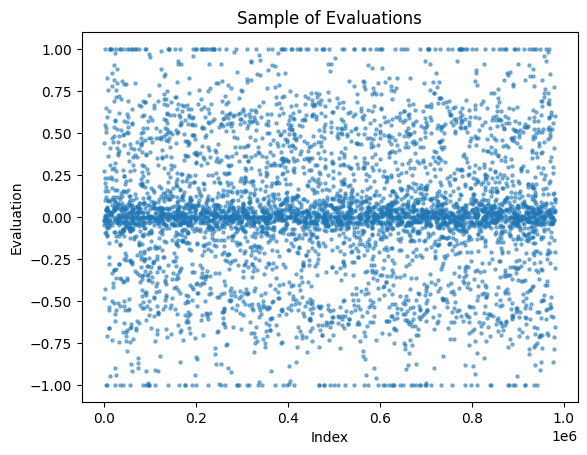

In [17]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

idx = np.random.choice(len(evaluations), size=5000, replace=False)
plt.scatter(idx, evaluations[idx], s=5, alpha=0.5)
plt.xlabel("Index")
plt.ylabel("Evaluation")
plt.title("Sample of Evaluations")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    positions, evaluations,
    test_size=0.25,       # 25%
    random_state=42,      # makes the split reproducible
    shuffle=True          # good default for random mixing
)

In [19]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(736174, 66) (736174,)
(245392, 66) (245392,)


In [20]:
# lets prepare our MLP
class MyModel(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = torch.nn.Linear(66, 66)
    self.relu1 = torch.nn.ReLU()
    self.fc2 = torch.nn.Linear(66, 128)
    self.relu2 = torch.nn.ReLU()
    self.fc3 = torch.nn.Linear(128, 128)
    self.relu3 = torch.nn.ReLU()
    self.fc4 = torch.nn.Linear(128, 66)
    self.relu4 = torch.nn.ReLU()
    self.out = torch.nn.Linear(66, 1)
    self.tanh = torch.nn.Tanh()

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu1(x)
    x = self.fc2(x)
    x = self.relu2(x)
    x = self.fc3(x)
    x = self.relu3(x)
    x = self.fc4(x)
    x = self.relu4(x)
    x = self.out(x)
    x = self.tanh(x)
    return x

In [25]:
# lets use a dataloader to divide the train_x and train_y in batches
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [22]:
# lets define the training
model = MyModel()  # neural network class
criterion = torch.nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 30

In [23]:
# if we want we can upload weights from file
# files.upload()
model.load_state_dict(torch.load("model_weights.pth"))


<All keys matched successfully>

In [21]:
# lets define the training
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_dataloader:
        optimizer.zero_grad()
        outputs = model(batch_x.float())
        loss = criterion(outputs, batch_y.float().unsqueeze(1))
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')
    # save weight to file every 20 epochs

torch.save(model.state_dict(), f"model_weights.pth")
# files.download(f"model_weights.pth")

Epoch 1/30, Loss: 0.1561
Epoch 2/30, Loss: 0.0842


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-2850696577.py", line 10, in <cell line: 0>
    for batch_x, batch_y in train_dataloader:
                            ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 734, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 790, in _next_data
    data = self._dataset_fetcher.fetch(index)  # may raise StopIteration
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/dat

TypeError: object of type 'NoneType' has no len()

In [26]:
# lets evaluate our model
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = model(inputs.float())
        loss = criterion(outputs, labels.unsqueeze(1).float())
        test_loss += loss.item() * inputs.size(0)
        # inputs.size(0) is the number of elements per batch
        # the MSE by default divides by the number of elements in batch so we multiply by it again in order to get back to the full loss

# since we have summed togheter the losses of every element in every batch we then divide by the number of elements total
test_loss /= len(test_dataset)
print(f'Test Loss (MSE): {test_loss:.4f}')

Test Loss (MSE): 0.0525


In [ ]:
''' The evaluation of our model shows a final test loss of ~0.05 and does not seem to be able to go lower
    this value is definitely too big to be acceptable: sqrt(0.05) = 0.224 which corresponds to 2.2 pawns.
    a +- 2.2 advantage in a chess game is the difference between being completely winning and completely lost.
'''

In [2]:
''' In the next cells there is some code to make the AI play itself, since I believe the MLP approach is not good enough I didn't bother to make the necessary
    adjustments to make it work properly, it should only bee a couple lines of code btw
'''

" In the next cells there is some code to make the AI play itself, since I believe the MLP approach is not good enough I didn't bother to make the necessary\nadjustments to make it work properly, it should only bee a couple lines of code btw "

In [ ]:
# ### THE FOLLOWING CODE IS LLM GENERATED, I DON'T TAKE RESPONSIBILITY FOR IT

# def board_to_vector(board): # THIS FUNCTION NEED ADJUSTMENTS TO WORK
#     """
#     Converts a chess.Board object to a 64-element NumPy array.
#     Each square is represented by a number corresponding to the piece on it.
#     """
#     piece_map = {"r":5,"n":3,"b":3.5,"q":9.5,"k":20,"p":1,"R":-5,"N":-3,"B":-3.5,"Q":-9.5,"K":-20,"P":-1, "." :0}

#     vector = np.zeros(64)
#     for i in range(64):
#         piece = board.piece_at(i)
#         if piece:
#             vector[i] = piece_map[piece.symbol()]
#     return vector

# def evaluate_board():
#     """
#     Evaluates the current board position.
#     Uses the PyTorch model for evaluation if not in a checkmate state.
#     """
#     if board.is_checkmate():
#         # If it's white's turn and it's checkmate, black won.
#         if board.turn == chess.WHITE:
#             return -9999
#         # If it's black's turn and it's checkmate, white won.
#         else:
#             return 9999

#     # Use the neural network for evaluation
#     with torch.no_grad(): # Disable gradient calculation for efficiency
#         # 1. Convert board to vector
#         board_vec = board_to_vector(board)

#         # 2. Convert NumPy array to PyTorch Tensor and add a batch dimension
#         input_tensor = torch.FloatTensor(board_vec).unsqueeze(0)

#         # 3. Get model output
#         output_tensor = model(input_tensor)

#         # 4. Extract the scalar value and scale it
#         # The model outputs a value in [-1, 1]. We scale it for the search algorithm.
#         evaluation = output_tensor.item() * 10

#         # The evaluation is from the perspective of the current player.
#         # We need to flip the sign if it's black's turn.
#         if board.turn == chess.BLACK:
#             return -evaluation

#         return evaluation


# # --- Search Algorithms (Alpha-Beta and Quiescence) ---
# # These functions remain largely the same as in your original code.

# def alphabeta(alpha, beta, depthleft):
#     bestscore = -9999
#     if depthleft == 0:
#         return quiesce(alpha, beta)

#     for move in board.legal_moves:
#         board.push(move)
#         score = -alphabeta(-beta, -alpha, depthleft - 1)
#         board.pop()

#         if score >= beta:
#             return score
#         if score > bestscore:
#             bestscore = score
#         if score > alpha:
#             alpha = score
#     return bestscore

# def quiesce(alpha, beta):
#     stand_pat = evaluate_board()
#     if stand_pat >= beta:
#         return beta
#     if alpha < stand_pat:
#         alpha = stand_pat

#     # Consider only capture moves for quiescence search
#     for move in board.legal_moves:
#         if board.is_capture(move):
#             board.push(move)
#             score = -quiesce(-beta, -alpha)
#             board.pop()

#             if score >= beta:
#                 return beta
#             if score > alpha:
#                 alpha = score
#     return alpha

# def selectmove(depth):
#     bestMove = chess.Move.null()
#     bestValue = -99999
#     alpha = -100000
#     beta = 100000

#     # Sort moves to improve alpha-beta pruning (optional but good practice)
#     # Here, we can do a simple sort or just iterate
#     moves = list(board.legal_moves)

#     for move in moves:
#         board.push(move)
#         boardValue = -alphabeta(-beta, -alpha, depth - 1)
#         if boardValue > bestValue:
#             bestValue = boardValue
#             bestMove = move
#         if boardValue > alpha:
#             alpha = boardValue
#         board.pop()

#     print(f"Best move: {bestMove} with evaluation: {bestValue}")
#     return bestMove


In [ ]:
# board = chess.Board()
# # let AI play against itself for a few moves
# for i in range(20):
#     print("\n" + "="*20)
#     print(f"Move #{i//2 + 1} {'White' if board.turn == chess.WHITE else 'Black'}'s turn")
#     print(board)

#     if board.is_game_over():
#         print("Game Over!")
#         print("Result: " + board.result())
#         break

#     move = selectmove(3) # using a depth of 2 for speed
#     if move == chess.Move.null():
#          print("No legal moves found.")
#          break

#     board.push(move)

# print("\nFinal Board Position:")
# print(board)